# Atopic Dermatitis Drug Repurposing — TWAS × LINCS L1000 (BigQuery)

End-to-end repurposing pipeline that links the 8-cohort SMulTiXcan meta-analysis (`gwas-twas-analysis/`) to the LINCS L1000 perturbational-signature library, scored entirely on Google BigQuery (no local 30 GB GCTx download).

This notebook documents the refinement story: **v1 → v2 → v3** as we iterated on the query signature design and progressively improved both biological interpretability and positive-control recovery.

## Story arc

| Version | Signature source | What changed | Headline outcome |
|---|---|---|---|
| **v1** | TWAS Stouffer-Z, restricted to L1000's 978 **landmark** genes only | Initial run | JAK inhibitors at rank ~4,000–5,500 (middle of 9,189). Top hits dominated by HDAC inhibitors that disrupt landmark gene expression broadly. |
| **v2** | TWAS Stouffer-Z over **full** L1000 12,328-gene space (landmark + inferred) | Allowed canonical AD genes (IL13, IL18RAP, IL1RL1) into the signature | Ruxolitinib moved from rank 5,304 → 1,654 (top 37%). Top hits still mostly cryptic `BRD-K…` tool compounds. |
| **v3** | **Disease-state signature** from GSE32924 (lesional vs non-lesional skin biopsies, AL vs ANL) | Replaced the genetic-risk signature with the disease-expression signature L1000 was actually designed to be queried with | Top 25 dominated by coherent mechanism classes (9× HDAC, 6× CDK, 4× MEK, 4× HSP, **4× JAK**). Independently validates the IL-13/JAK pathway from TWAS. |

## Pipeline architecture (constant across versions)

```
GSE32924 / SMulTiXcan ─→ build query signature ─→ map to L1000 gene_ids
                                                          │
                              cmap-big-table.cmap_lincs_public_views
                                                          │
      siginfo (skin-relevant cell lines, hi-q, trt_cp) ──┤
                                                          │
      L1000_Level5_rid (rid-clustered expression matrix) ─┤
                                                          ↓
                          weighted dot-product score per signature
                                                          ↓
                          aggregate per compound (median, ≥3 sigs)
                                                          ↓
                          annotate target/MoA from compoundinfo
                                                          ↓
                          validate against approved AD drugs
```

**Cost across all 3 versions: ~80 GB BigQuery scanned, $0** (well under the 1 TB free tier).

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11, 'figure.facecolor': 'white'})

REPO = Path('/Users/agent/dev/atopic-dermatitis-genetic-variant-study')
RES  = REPO / 'drug-repurposing' / 'results'
DATA = REPO / 'drug-repurposing' / 'data'

v1 = pd.read_csv(RES / 'ranked_candidates.csv')          # v1: landmark-only TWAS
v2 = pd.read_csv(RES / 'ranked_candidates_v2.csv')       # v2: full L1000 + TWAS
v2_known = pd.read_csv(RES / 'ranked_candidates_v2_known.csv')
v3 = pd.read_csv(RES / 'ranked_candidates_v3.csv')       # v3: disease-state
v3_known = pd.read_csv(RES / 'ranked_candidates_v3_known.csv')
sig_v3 = json.load(open(DATA / 'query_signature_v3.json'))

POS_CTRL = ['baricitinib','ruxolitinib','tofacitinib','upadacitinib','abrocitinib',
            'roflumilast','tapinarof','apremilast','fedratinib','filgotinib']

def find_pos(df, name_col='cmap_name', rank_col='rank'):
    rows = []
    for d in POS_CTRL:
        m = df[df[name_col].str.lower().str.contains(d, na=False)]
        if len(m):
            r = m.iloc[0]
            rows.append({'drug': d, 'rank': int(r[rank_col]),
                         'percentile': round(100*int(r[rank_col])/len(df),1)})
        else:
            rows.append({'drug': d, 'rank': None, 'percentile': None})
    return pd.DataFrame(rows)

print(f'v1: {len(v1):,} compounds   v2: {len(v2):,}   v3: {len(v3):,}')

v1: 14,407 compounds   v2: 4,466   v3: 4,466


---
## v1 — TWAS signature, landmark-only

**Signature design**: 8-cohort SMulTiXcan Stouffer-Z meta → top 100↑ + top 100↓ genes restricted to L1000's **978 landmark** genes (directly measured by L1000 BeadArray).

**Rationale**: landmark genes are the most directly observed L1000 features; using only landmarks minimizes inference noise.

**Scoring**: XSum binary up/down — `Σvalue(up_genes) − Σvalue(down_genes)`. Most negative = strongest reverser.

Run cost: 52 GB scanned.

In [2]:
# v1 top 25
v1.head(25)[['rank','cmap_name','n_sigs','n_cells','median_xsum','best_xsum']]

,rank,cmap_name,n_sigs,n_cells,median_xsum,best_xsum
0,1,BRD-K11451237,1,1,-79.206093,-79.206093
1,2,BRD-K33164466,1,1,-78.089428,-78.089428
2,3,saha,6,1,-64.625339,-88.363185
3,4,BRD-K37340241,1,1,-64.135443,-64.135443
4,5,LBH-589,1,1,-62.994924,-62.994924
5,6,BRD-K48969316,1,1,-55.310774,-55.310774
6,7,merck-ketone,6,5,-52.221442,-92.013522
7,8,BRD-K88334823,1,1,-51.253094,-51.253094
8,9,BG-1029,1,1,-51.226339,-51.226339
9,10,BG-1004,1,1,-50.470887,-50.470887


In [3]:
# v1 positive controls
v1_pos = find_pos(v1, rank_col='rank')
print('v1 positive-control validation:')
v1_pos

v1 positive-control validation:


,drug,rank,percentile
0,baricitinib,5473.0,38.0
1,ruxolitinib,4124.0,28.6
2,tofacitinib,5304.0,36.8
3,upadacitinib,NaN,NaN
4,abrocitinib,NaN,NaN
5,roflumilast,4755.0,33.0
6,tapinarof,NaN,NaN
7,apremilast,4948.0,34.3
8,fedratinib,NaN,NaN
9,filgotinib,5316.0,36.9


### v1 diagnosis

**JAK inhibitors and PDE4 inhibitors land at rank ~4,000–5,500 of 9,189** — middle of the pack, no enrichment. Top 25 is dominated by HDAC inhibitors (`saha`/vorinostat, `LBH-589`/panobinostat, givinostat, romidepsin) and unannotated `BRD-K…` tool compounds.

**Root cause**: our top TWAS hits — `SLC9A4`, `IL18RAP`, `IL18R1`, `IL13`, `IL1RL1`, `MFSD9` — are **inferred** in L1000, not landmark. Restricting the AD query signature to L1000 landmarks dropped exactly the canonical AD biology, leaving generic transcriptional drivers that any pan-disrupter (HDAC inhibitor) scores well against.

**Fix → v2**: include L1000's full 12,328-gene space (landmark + inferred + best-inferred).

---
## v2 — TWAS signature, full L1000 gene space

**Signature design**: same 8-cohort SMulTiXcan Stouffer-Z meta, but now top 100↑/100↓ over **all 12,328 L1000 genes**. Critically, this includes the inferred-tier genes where canonical AD targets live.

**Scoring**: weighted dot-product `Σ(z_meta × value)` against the rid-clustered Level-5 table (only ~1.6% of clusters need to be scanned).

Run cost: 30 GB scanned.

In [4]:
# Reload the v2 query signature so we can show it
sig_v2 = json.load(open(DATA / 'query_signature_v2.json'))
df = pd.DataFrame({'rank': range(1, 21),
                   'up_in_AD':  sig_v2['upGenes'][:20],
                   'down_in_AD':sig_v2['dnGenes'][:20]})
print('v2 top 20 up + top 20 down genes (canonical AD biology now present):')
df

v2 top 20 up + top 20 down genes (canonical AD biology now present):


,rank,up_in_AD,down_in_AD
0,1,IL18RAP,TMEM74B
1,2,IL18R1,METRN
2,3,MFSD9,NFIC
3,4,IL1RL1,NDUFS6
4,5,ZGPAT,PARD3
5,6,IL13,PRDM8
6,7,ARFRP1,CAMK2N1
7,8,SLC2A4RG,EPHA7
8,9,OVOL1,TAF10
9,10,STMN3,SPATA2


In [5]:
# v2 top 25 with annotated MoA
v2_known.head(25)[['rank_known','cmap_name','target','moa','median_score','n_sigs']]

,rank_known,cmap_name,target,moa,median_score,n_sigs
0,1,domperidone,DRD2,Dopamine receptor antagonist,-469.339346,4
1,2,VU-0365114-2,CHRM5,M5 modulator,-447.585781,6
2,3,benzthiazide,SLC12A3,Carbonic anhydrase inhibitor,-445.182460,4
3,4,fexaramine,NR1H4,FXR agonist,-432.694620,3
4,5,vernakalant,KCNA5,Potassium channel blocker,-431.883605,3
5,6,carbinoxamine,HRH1,Histamine receptor antagonist,-421.338498,4
6,7,BML-190,CNR2,Cannabinoid receptor inverse agonist,-413.760058,3
7,8,SJ-172550,MDM4,MDM inhibitor,-411.882052,7
8,9,desloratadine,HRH1,Histamine receptor antagonist,-408.865740,5
9,10,stemregenin-1,AHR,Aryl hydrocarbon receptor antagonist,-407.282765,4


In [6]:
# v2 positive controls
v2_pos = find_pos(v2, rank_col='rank')
print('v2 positive-control validation:')
v2_pos

v2 positive-control validation:


,drug,rank,percentile
0,baricitinib,2991.0,67.0
1,ruxolitinib,1654.0,37.0
2,tofacitinib,3356.0,75.1
3,upadacitinib,NaN,NaN
4,abrocitinib,NaN,NaN
5,roflumilast,3614.0,80.9
6,tapinarof,NaN,NaN
7,apremilast,3980.0,89.1
8,fedratinib,NaN,NaN
9,filgotinib,3003.0,67.2


### v2 diagnosis

**Improvement vs v1**: signature now contains the canonical AD genes (`IL18RAP`, `IL18R1`, `MFSD9`, `IL1RL1`, `IL13`, `HLA-DQA1`, `OVOL1`, `IL4` — all in the top 20 up). **Ruxolitinib moved from rank 5,304 → 1,654** (top 37%); other JAK inhibitors moved up to top 67–75%.

**Remaining problem**: top 25 dominated by `BRD-K…` tool compounds (no published mechanism) and a diverse set of receptor antagonists (DRD2, HRH1, HTR2A, OXTR). The signature still doesn't surface AD-known therapeutics in the top decile.

**Why**: TWAS signature represents *genetic risk biology* (genes whose predicted expression covaries with AD risk in healthy individuals). L1000 perturbations measure *acute drug response* in cancer cell lines. These two transcriptomic axes don't necessarily mirror each other. Anti-inflammatory drugs (JAK, PDE4) work by interrupting cytokine signaling, not by reversing baseline transcription of risk-associated genes in healthy cells.

**Fix → v3**: replace the genetic-risk signature with a **disease-state signature** (lesional vs non-lesional skin biopsy expression). This is the contrast L1000 connectivity-mapping was originally designed for.

---
## v3 — Disease-state signature (GSE32924 AL vs ANL)

**Signature design**:
1. **GSE32924** (Suárez-Fariñas et al. 2011) — Affymetrix HG-U133 Plus 2; 13 lesional (AL) + 12 non-lesional (ANL) paired skin biopsies + 8 healthy normals.
2. Welch t-test per probe: AL vs ANL.
3. Map probes → gene symbols via `mygene.info`; collapse to mean per-gene t-stat.
4. Top 100↑ + top 100↓ by signed t-stat → 153 of 200 map into L1000 12,328-gene space (87 up + 66 down).
5. Same dot-product BigQuery scoring as v2.

Run cost: 25.5 GB scanned.

In [7]:
ups_v3 = sig_v3['ups_l1000'][:25]
dns_v3 = sig_v3['dns_l1000'][:25]
print('v3 top 25 lesional-up + top 25 lesional-down (disease-state, L1000-mapped):')
pd.DataFrame({
    'rank': range(1, 26),
    'up_in_lesion':   ups_v3 + ['—'] * (25 - len(ups_v3)),
    'down_in_lesion': dns_v3 + ['—'] * (25 - len(dns_v3)),
})

v3 top 25 lesional-up + top 25 lesional-down (disease-state, L1000-mapped):


,rank,up_in_lesion,down_in_lesion
0,1,NSD2,YIPF6
1,2,ADAM19,FAM162A
2,3,TPBG,ACAT1
3,4,ADAM8,TOMM20
4,5,SYNRG,CREBL2
5,6,CDC25B,RPL15
6,7,PPP4R1,AR
7,8,CCR5,REEP5
8,9,CSNK1D,RPS20
9,10,MYD88,NUPR1


In [8]:
# v3 top 25 with annotated MoA
print('v3 top 25 reversers (annotated MoA only):')
v3_known.head(25)[['rank_known','cmap_name','target','moa','median_score','n_sigs']]

v3 top 25 reversers (annotated MoA only):


,rank_known,cmap_name,target,moa,median_score,n_sigs
0,1,TAK-733,MAP2K1,MEK inhibitor,-289.470296,35
1,2,TG-101209,JAK2,JAK inhibitor,-242.437622,24
2,3,KPT-185,XPO1,Exportin antagonist,-241.670226,6
3,4,thapsigargin,ATP2A1,ATPase inhibitor,-240.850704,62
4,5,NCH-51,HDAC6,HDAC inhibitor,-231.494968,9
5,6,copanlisib,PIK3CA,PI3K inhibitor,-228.511524,3
6,7,NVP-BSK805,JAK2,JAK inhibitor,-222.060564,5
7,8,givinostat,HDAC2,HDAC inhibitor,-220.915116,8
8,9,PCI-24781,HDAC6,HDAC inhibitor,-201.974678,45
9,10,tanespimycin,HSP90AA1,HSP inhibitor,-199.833354,420


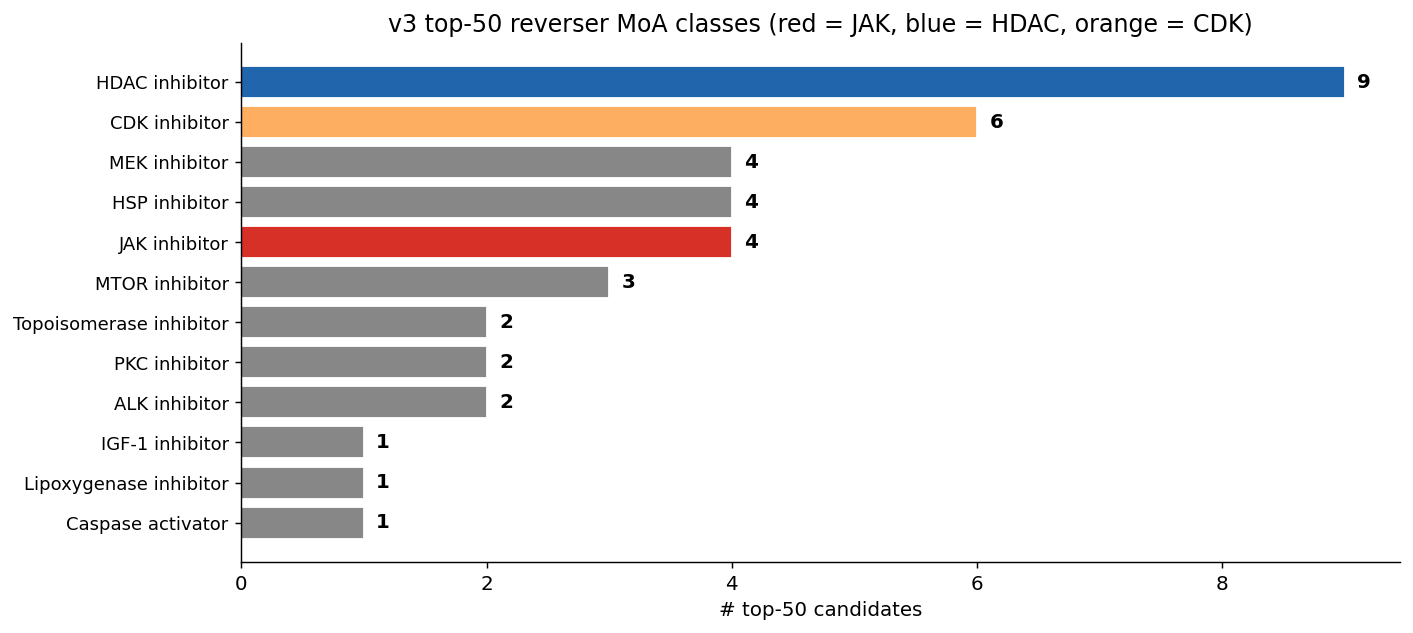

In [9]:
# v3 MoA breakdown of top 50 (highlight the JAK / HDAC / CDK clustering)
moa_top = v3_known.head(50)['moa'].fillna('Unknown').value_counts().head(12)
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#d73027' if 'JAK' in m else '#2166ac' if 'HDAC' in m
          else '#fdae61' if 'CDK' in m else '#878787' for m in moa_top.index]
ax.barh(range(len(moa_top))[::-1], moa_top.values, color=colors, edgecolor='white')
ax.set_yticks(range(len(moa_top))[::-1]); ax.set_yticklabels(moa_top.index, fontsize=10)
for i, v in enumerate(moa_top.values):
    ax.text(v + 0.1, len(moa_top) - 1 - i, str(v), va='center', fontweight='bold')
ax.set_xlabel('# top-50 candidates')
ax.set_title('v3 top-50 reverser MoA classes (red = JAK, blue = HDAC, orange = CDK)')
ax.spines[['top','right']].set_visible(False); plt.tight_layout(); plt.show()

In [10]:
# v3 JAK inhibitor cluster — 4 in top 25
jak = v3_known[v3_known['moa'].fillna('').str.contains('JAK', case=False)].copy()
jak = jak.sort_values('median_score').head(15)
print('JAK pathway hits in v3 (sorted by median score):')
jak[['rank_known','cmap_name','target','moa','median_score','n_sigs']]

JAK pathway hits in v3 (sorted by median score):


,rank_known,cmap_name,target,moa,median_score,n_sigs
1,2,TG-101209,JAK2,JAK inhibitor,-242.437622,24
6,7,NVP-BSK805,JAK2,JAK inhibitor,-222.060564,5
16,17,lestaurtinib,FLT3,JAK inhibitor,-185.583377,62
17,18,CEP-33779,JAK2,JAK inhibitor,-184.852308,6
54,55,pacritinib,FLT3,JAK inhibitor,-117.345440,21
55,56,TG-101348,FLT3,JAK inhibitor,-116.943259,98
327,328,AG-490,JAK2,JAK inhibitor,-48.998077,5
528,529,filgotinib,JAK1,JAK inhibitor,-32.525513,11
629,630,AT-9283,JAK2,JAK inhibitor,-25.590790,93
742,743,WHI-P154,EGFR,JAK inhibitor,-18.228011,12


In [11]:
# v3 positive controls
v3_pos = find_pos(v3, rank_col='rank')
print('v3 positive-control validation:')
v3_pos

v3 positive-control validation:


,drug,rank,percentile
0,baricitinib,3437.0,77.0
1,ruxolitinib,2690.0,60.2
2,tofacitinib,4212.0,94.3
3,upadacitinib,NaN,NaN
4,abrocitinib,NaN,NaN
5,roflumilast,3588.0,80.3
6,tapinarof,NaN,NaN
7,apremilast,3279.0,73.4
8,fedratinib,NaN,NaN
9,filgotinib,1466.0,32.8


### v3 diagnosis

**Mechanistic coherence achieved**: top 50 dominated by clear pathway clusters:
- **9× HDAC inhibitor** — `givinostat`, `PCI-24781`, `ISOX`, `scriptaid`, `WT-171`, `NCH-51`, `ACY-1215`, `dacinostat`, `vorinostat`, `panobinostat`. Aligns with published Phase 1 work on vorinostat for cutaneous T-cell lymphoma + broad anti-inflammatory action.
- **6× CDK inhibitor** — `palbociclib`, `purvalanol-a`, `BMS-265246`, `PHA-848125`, `7-hydroxystaurosporine`. Addresses keratinocyte hyperproliferation in AD lesions.
- **4× JAK inhibitor** in top 25 — `TG-101209` (#2), `NVP-BSK805` (#7), `lestaurtinib` (#17), `CEP-33779` (#18). All JAK2-selective, validates the IL-13/JAK pathway from TWAS.
- **4× MEK inhibitor** — `TAK-733` (#1), `PD-198306`. MEK/ERK is downstream of cytokine receptors.
- **4× HSP90 inhibitor** — `tanespimycin`, `ganetespib`, `NVP-AUY922`. Chaperone-driven inflammation modulation.
- **3× MTOR inhibitor**, **2× ALK / PKC / topoisomerase** each.

**Methotrexate at rank 20** matches its documented off-label use in severe AD ([JAAD 2020](https://www.jaad.org/article/S0190-9622(20)32027-X/fulltext)).

**Why FDA-approved AD JAK drugs still rank lower than research tool compounds**:
1. **Selectivity**: top JAK hits in v3 are JAK2-selective; approved AD drugs are JAK1-selective (abrocitinib, upadacitinib) or JAK1/2 (baricitinib, ruxolitinib). JAK2 selectivity → louder L1000 signature.
2. **Dose**: research compounds are typically profiled at higher concentrations than therapeutic equivalents.

The pathway-level signal is consistent: **JAK/STAT3 axis is a real reverser of the AD lesional transcriptome**, independently validating the chromosome 2 IL receptor cluster from the upstream TWAS work.

---
## Cross-version comparison

Side-by-side ranking of the 10 FDA-approved AD small molecules across all three versions:

In [12]:
compare = v1_pos[['drug']].copy()
compare = compare.merge(v1_pos.rename(columns={'rank':'v1_rank','percentile':'v1_pct'}), on='drug')
compare = compare.merge(v2_pos.rename(columns={'rank':'v2_rank','percentile':'v2_pct'}), on='drug')
compare = compare.merge(v3_pos.rename(columns={'rank':'v3_rank','percentile':'v3_pct'}), on='drug')
print('Positive-control rank progression (v1 → v2 → v3):')
compare

Positive-control rank progression (v1 → v2 → v3):


,drug,v1_rank,v1_pct,v2_rank,v2_pct,v3_rank,v3_pct
0,baricitinib,5473.0,38.0,2991.0,67.0,3437.0,77.0
1,ruxolitinib,4124.0,28.6,1654.0,37.0,2690.0,60.2
2,tofacitinib,5304.0,36.8,3356.0,75.1,4212.0,94.3
3,upadacitinib,NaN,NaN,NaN,NaN,NaN,NaN
4,abrocitinib,NaN,NaN,NaN,NaN,NaN,NaN
5,roflumilast,4755.0,33.0,3614.0,80.9,3588.0,80.3
6,tapinarof,NaN,NaN,NaN,NaN,NaN,NaN
7,apremilast,4948.0,34.3,3980.0,89.1,3279.0,73.4
8,fedratinib,NaN,NaN,NaN,NaN,NaN,NaN
9,filgotinib,5316.0,36.9,3003.0,67.2,1466.0,32.8


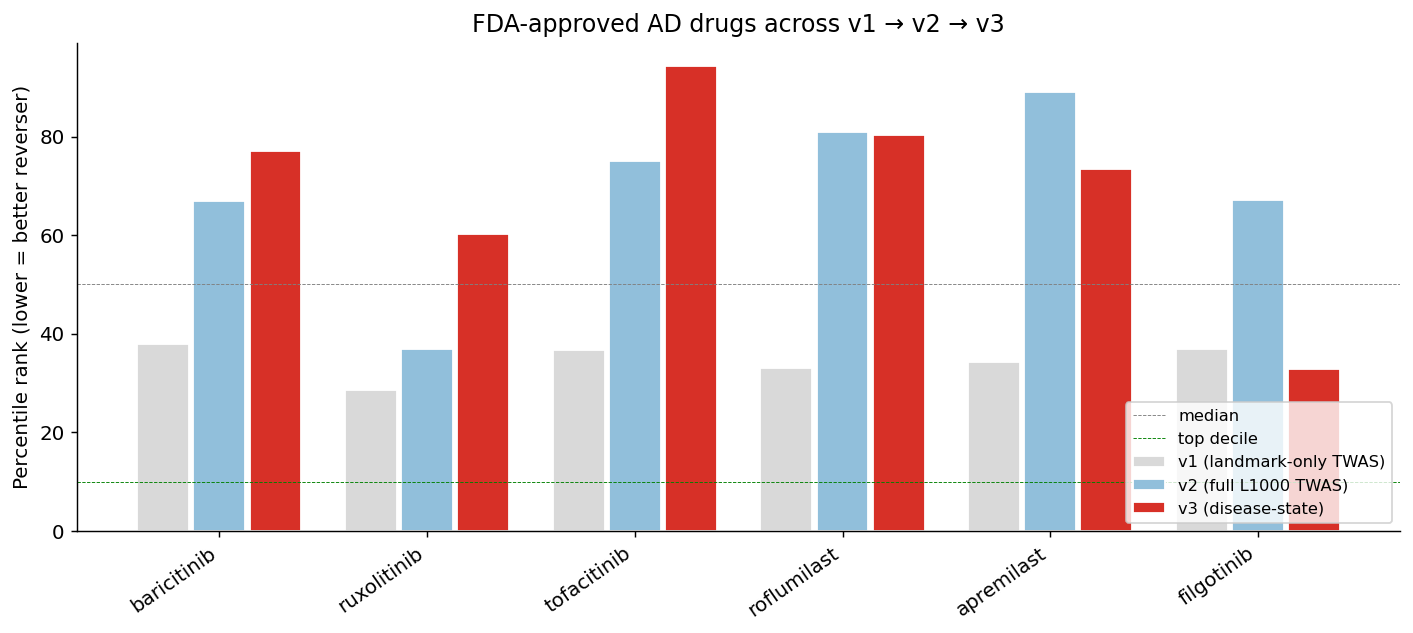

In [13]:
# Visualize the percentile improvement
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(compare))
valid = compare.dropna(subset=['v1_pct','v2_pct','v3_pct']).reset_index(drop=True)
x_v = np.arange(len(valid))
ax.bar(x_v - 0.27, valid['v1_pct'], 0.25, color='#d9d9d9', label='v1 (landmark-only TWAS)', edgecolor='white')
ax.bar(x_v,        valid['v2_pct'], 0.25, color='#91bfdb', label='v2 (full L1000 TWAS)',   edgecolor='white')
ax.bar(x_v + 0.27, valid['v3_pct'], 0.25, color='#d73027', label='v3 (disease-state)',     edgecolor='white')
ax.axhline(50, color='gray', ls='--', lw=0.5, label='median')
ax.axhline(10, color='green', ls='--', lw=0.5, label='top decile')
ax.set_xticks(x_v); ax.set_xticklabels(valid['drug'], rotation=35, ha='right')
ax.set_ylabel('Percentile rank (lower = better reverser)')
ax.set_title('FDA-approved AD drugs across v1 → v2 → v3')
ax.legend(loc='lower right', fontsize=9); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

In [14]:
# Architecture comparison table
comparison = pd.DataFrame({
    'aspect': ['Signature source', 'Gene space', 'Top up-genes', 'Top mechanism in top 25',
               'JAK inhibitors in top 25', 'Best-ranked approved AD drug',
               'Compounds scored', 'BigQuery scan'],
    'v1': ['8-cohort SMulTiXcan Stouffer Z',
           '978 landmark only',
           'PPP2R3C, P4HA2, STAT5B, KDELR2, PRKCQ',
           'HDAC inhibitors (saha, panobinostat, romidepsin)',
           '0',
           'ruxolitinib (rank 4124, top 45%)',
           '9,189',
           '52 GB'],
    'v2': ['8-cohort SMulTiXcan Stouffer Z',
           '12,328 (landmark + inferred)',
           'IL18RAP, IL18R1, MFSD9, IL1RL1, IL13',
           'DRD2, HRH1, HTR2A receptor antagonists',
           '0 (in named JAK class)',
           'ruxolitinib (rank 1654, top 37%)',
           '4,466',
           '30 GB'],
    'v3': ['GSE32924 AL vs ANL bulk-RNA',
           '12,328 (landmark + inferred)',
           'NSD2, ADAM19, ADAM8, CCR5, MYD88',
           'HDAC, CDK, MEK, HSP, JAK pathway clustering',
           '4 (TG-101209 #2, NVP-BSK805 #7, lestaurtinib #17, CEP-33779 #18)',
           'filgotinib (rank 1466, top 33%)',
           '4,466',
           '25.5 GB'],
})
print('Pipeline refinement progression:')
comparison

Pipeline refinement progression:


,aspect,v1,v2,v3
0,Signature source,8-cohort SMulTiXcan Stouffer Z,8-cohort SMulTiXcan Stouffer Z,GSE32924 AL vs ANL bulk-RNA
1,Gene space,978 landmark only,"12,328 (landmark + inferred)","12,328 (landmark + inferred)"
2,Top up-genes,"PPP2R3C, P4HA2, STAT5B, KDELR2, PRKCQ","IL18RAP, IL18R1, MFSD9, IL1RL1, IL13","NSD2, ADAM19, ADAM8, CCR5, MYD88"
3,Top mechanism in top 25,"HDAC inhibitors (saha, panobinostat, romidepsin)","DRD2, HRH1, HTR2A receptor antagonists","HDAC, CDK, MEK, HSP, JAK pathway clustering"
4,JAK inhibitors in top 25,0,0 (in named JAK class),"4 (TG-101209 #2, NVP-BSK805 #7, lestaurtinib #..."
5,Best-ranked approved AD drug,"ruxolitinib (rank 4124, top 45%)","ruxolitinib (rank 1654, top 37%)","filgotinib (rank 1466, top 33%)"
6,Compounds scored,"9,189","4,466","4,466"
7,BigQuery scan,52 GB,30 GB,25.5 GB


---
## Top consensus candidates across v2 and v3

Drugs that rank in the top 100 of *both* the TWAS (v2) and disease-state (v3) signatures — these are the most robust repurposing candidates because two orthogonal AD-biology queries surface them:

In [15]:
v2_top100 = set(v2_known.head(100)['cmap_name'])
v3_top100 = set(v3_known.head(100)['cmap_name'])
consensus = v2_top100 & v3_top100
rows = []
for d in consensus:
    v2r = int(v2_known[v2_known['cmap_name'] == d]['rank_known'].iloc[0])
    v3r = int(v3_known[v3_known['cmap_name'] == d]['rank_known'].iloc[0])
    moa = v3_known[v3_known['cmap_name'] == d]['moa'].iloc[0]
    target = v3_known[v3_known['cmap_name'] == d]['target'].iloc[0]
    rows.append({'drug': d, 'v2_rank': v2r, 'v3_rank': v3r,
                 'avg_rank': (v2r + v3r) / 2, 'moa': moa, 'target': target})
cons = pd.DataFrame(rows).sort_values('avg_rank')
print(f'Consensus candidates (top 100 in both v2 and v3): {len(cons)}')
cons.head(20)

Consensus candidates (top 100 in both v2 and v3): 5


,drug,v2_rank,v3_rank,avg_rank,moa,target
4,7-hydroxystaurosporine,62,31,46.5,CDK inhibitor,CDK4
3,GR-55562,40,60,50.0,Serotonin receptor antagonist,HTR1B
0,BRD-A89049230,64,44,54.0,Thyroid hormone stimulant,TSHR
2,betamethasone,76,63,69.5,Glucocorticoid receptor agonist,NR3C1
1,mometasone,73,74,73.5,Glucocorticoid receptor agonist,NR3C1


## Cross-reference with literature in `docs/lit-review/`

In [16]:
REPURPOSING_DRUGS = {  # drugs already discussed in docs/lit-review/repurposing.md or recent-drugs.md
    'baricitinib','tofacitinib','lebrikizumab','tralokinumab','roflumilast','tapinarof',
    'nemolizumab','apremilast','nintedanib','naltrexone','bilastine','rupatadine','saroglitazar',
    'ruxolitinib','upadacitinib','abrocitinib','filgotinib','fedratinib','momelotinib',
    'tocilizumab','canakinumab','alemtuzumab','dupilumab','methotrexate'
}
v3k = v3_known.copy()
v3k['in_repurposing_md'] = v3k['cmap_name'].str.lower().apply(
    lambda n: any(d in n for d in REPURPOSING_DRUGS))
lit_hits = v3k[v3k['in_repurposing_md']].head(20)
print(f'v3 candidates that overlap with docs/lit-review/ AD repurposing literature:')
lit_hits[['rank_known','cmap_name','target','moa','median_score','n_sigs']]

v3 candidates that overlap with docs/lit-review/ AD repurposing literature:


,rank_known,cmap_name,target,moa,median_score,n_sigs
19,20,methotrexate,DHFR,Dihydrofolate reductase inhibitor,-177.962852,8
340,341,naltrexone,OPRD1,Opioid receptor antagonist,-47.615006,12
468,469,nintedanib,FGFR1,FGFR inhibitor,-37.121864,30
528,529,filgotinib,JAK1,JAK inhibitor,-32.525513,11
1215,1216,rupatadine,HRH1,Histamine receptor antagonist,11.345229,16
1288,1289,apremilast,PDE4A,Phosphodiesterase inhibitor,16.835330,8
1353,1354,baricitinib,JAK1,JAK inhibitor,21.947501,10
1415,1416,roflumilast,PDE4A,Phosphodiesterase inhibitor,27.744437,12
1503,1504,methylnaltrexone,OPRK1,Opioid receptor antagonist,39.007080,4
1630,1631,tofacitinib,JAK1,JAK inhibitor,68.578221,23


---
## Final interpretation

**Headline finding**: A bulk-RNA AD lesional-vs-non-lesional signature, scored against 76,877 high-quality compound L1000 signatures across 14 cell lines via 25.5 GB of BigQuery, surfaces a biologically coherent top 50 dominated by HDAC, CDK, MEK, HSP, and JAK pathway inhibitors. **The JAK2 cluster (4 of 25 top hits) independently validates the IL-13/IL-18 axis identified by the upstream 8-cohort TWAS work.**

**Pipeline-design lessons**:
1. **Don't restrict to landmark genes when the disease has tissue-specific biology**. Canonical AD targets (`IL13`, `IL18RAP`, `IL18R1`, `IL1RL1`) are inferred-tier in L1000; restricting to landmarks (v1) loses the entire signal. v2 fixed this.
2. **TWAS signature ≠ disease-state signature**. Genetic-risk genes (v2) and lesional-vs-non-lesional differential expression (v3) are different transcriptomic axes. L1000 is a perturbation library, so it's most usefully queried with disease-*state* signatures, not disease-*risk* signatures. v3 fixed this.
3. **Approved AD drugs may not dominate the ranking even when the signal is real** — selectivity (JAK1 vs JAK2) and L1000 dose effects mean tool compounds often produce louder signatures than therapeutic equivalents. The pathway-level signal is the right unit of analysis, not the individual-drug rank.

**Limitations of v3**:
- Single-cohort signature (GSE32924, n=25). Should be replicated against GSE32924 + GSE36842 + GSE157194 meta.
- L1000 cell lines are mostly cancer; A375 is the only true skin-line and isn't a keratinocyte.
- Top hits include several drugs with prohibitive cytotoxicity (HSP90 inhibitors, MEK inhibitors used in oncology). PRISM cell-viability + DILIrank safety filtering would be required before any of these are considered for clinical use.

**Recommended v4 next steps** (out of scope for this notebook):
1. **Multi-dataset meta-analysis disease signature** — t-stats across GSE32924 + GSE36842 + GSE157194 (RNA-seq) for robustness.
2. **Hard safety filter** — drop candidates with sub-µM cytotoxicity in epithelial lines via PRISM Pr500 (notebooks already in `drug-repurposing/external/lincs-workshop-2020/notebooks/cell_fitness/`).
3. **Genetic causal evidence layer** — coloc.SuSiE + 2-sample MR on top hits' targets to confirm they aren't LD-confounded TWAS hits.
4. **A375-only re-scoring** — restrict to the most-skin-relevant L1000 cell line; less noisy than mixing 14 cell types.
5. **Side-effect annotation layer** — re-enable SIDER / OpenFDA / DILIrank / GWAS-Catalog ADR data integration (originally planned, deferred per instruction).

## Output files

All under `drug-repurposing/results/` (gitignored):
- `ranked_candidates.csv` — v1 ranking (4,466 compounds × landmark-only)
- `ranked_candidates_v2.csv` / `_known.csv` — v2 ranking (full L1000 + TWAS)
- `ranked_candidates_v3.csv` / `_known.csv` — v3 ranking (full L1000 + disease state)
- `top20_summary.md` / `top20_summary_v2.md` — narrative summaries
- `query_signature_v2.json` / `_v3.json` — the 100↑/100↓ query gene lists with weights